# Outliers and High-Leverage Points

When we fit a regression, not all observations contribute equally — and some can have an outsized effect on the model. There are two distinct ways an observation can be unusual:

- An **outlier** has an unusual *response value* given its predictors — it sits far from the regression line in the y-direction. Large residual.
- A **high-leverage point** has unusual *predictor values* — it sits far from the center of the x-distribution. It pulls the regression line toward it.

A point can be one, both, or neither. The combination of both — an outlier that also has high leverage — is the most dangerous, because it can dramatically distort the fitted line while appearing to fit well.

In this notebook we’ll cover:
- Studentized residuals for identifying outliers
- The leverage statistic (hat value) for identifying high-leverage points
- Cook’s distance as a combined measure of influence
- Standard regression diagnostic plots
- An interactive widget to see how adding a suspicious observation affects all three measures

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats

import ipywidgets as widgets
from ipywidgets import interact

import warnings
warnings.filterwarnings('ignore')

plt.rc('figure', figsize=(12, 5))

In [2]:
url = 'https://raw.githubusercontent.com/dsahota-applied-data-analysis/data/main/Auto.csv'
auto = pd.read_csv(url, na_values='?').dropna()
auto['horsepower'] = auto['horsepower'].astype(float)
auto = auto[['mpg', 'horsepower']].copy()

model = smf.ols('mpg ~ horsepower', auto).fit()
print(model.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     39.9359      0.717     55.660      0.000      38.525      41.347
horsepower    -0.1578      0.006    -24.489      0.000      -0.171      -0.145


Text(0.5, 0, 'Horsepower')

Text(0, 0.5, 'MPG')

Text(0.5, 1.0, 'MPG vs Horsepower — Auto dataset')

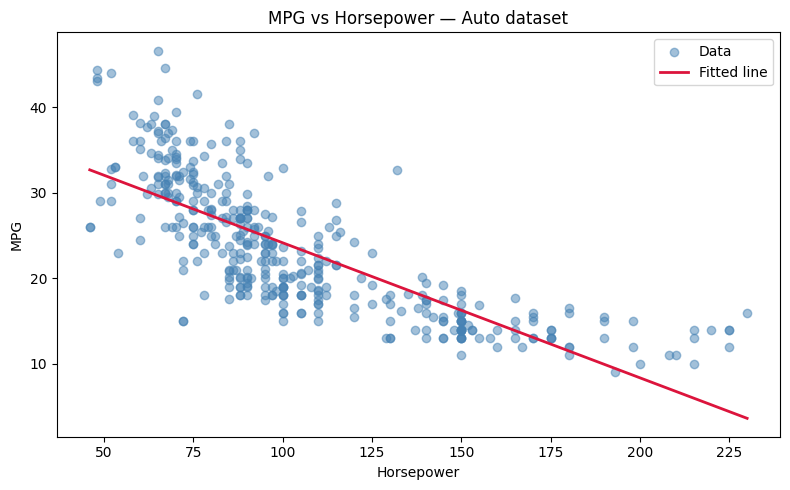

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(auto['horsepower'], auto['mpg'], alpha=0.5, color='steelblue', label='Data')
hp_range = np.linspace(auto['horsepower'].min(), auto['horsepower'].max(), 200)
ax.plot(hp_range, model.predict(pd.DataFrame({'horsepower': hp_range})),
        color='crimson', linewidth=2, label='Fitted line')
ax.set_xlabel('Horsepower')
ax.set_ylabel('MPG')
ax.set_title('MPG vs Horsepower — Auto dataset')
ax.legend()
plt.tight_layout()
plt.show()

## Part 1: Studentized Residuals — Detecting Outliers

A plain residual ($y_i - \hat{y}_i$) isn’t directly comparable across observations because residuals naturally have different variances. **Studentized residuals** divide each residual by an estimate of its standard deviation, producing a value that behaves like a t-statistic.

The *externally studentized* (or *studentized deleted*) residual for observation $i$ is computed by:
1. Fitting the model *without* observation $i$
2. Using that model to predict $y_i$
3. Dividing the resulting residual by its estimated standard error

Observations with a studentized residual larger than 3 in absolute value are commonly flagged as potential outliers.

In [4]:
influence = model.get_influence()
student_resid = influence.resid_studentized_external
leverage      = influence.hat_matrix_diag
cooks_d       = influence.cooks_distance[0]

diag = pd.DataFrame({
    'horsepower':      auto['horsepower'].values,
    'mpg':             auto['mpg'].values,
    'fitted':          model.fittedvalues.values,
    'student_resid':   student_resid,
    'leverage':        leverage,
    'cooks_d':         cooks_d
})

n = len(diag)
p = 1  # one predictor

print(f'Observations flagged by studentized residual (|e| > 3):')
print(diag[diag['student_resid'].abs() > 3][['horsepower', 'mpg', 'student_resid']])

Observations flagged by studentized residual (|e| > 3):
     horsepower   mpg  student_resid
320        65.0  46.6       3.508709
327        67.0  44.6       3.149671


Text(0.5, 0, 'Fitted values')

Text(0, 0.5, 'Studentized residual')

Text(0.5, 1.0, 'Residuals vs Fitted')

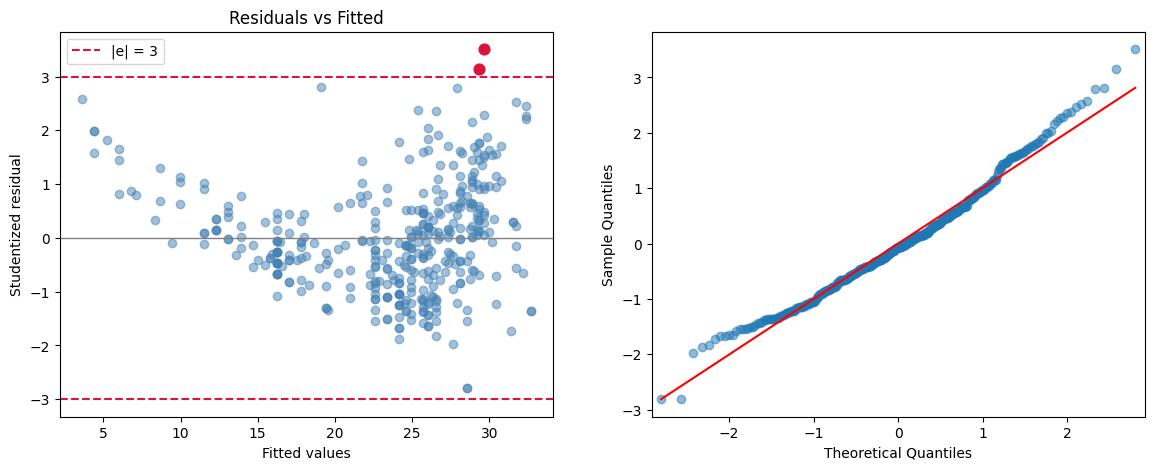

Text(0.5, 1.0, 'Q-Q Plot of Studentized Residuals')

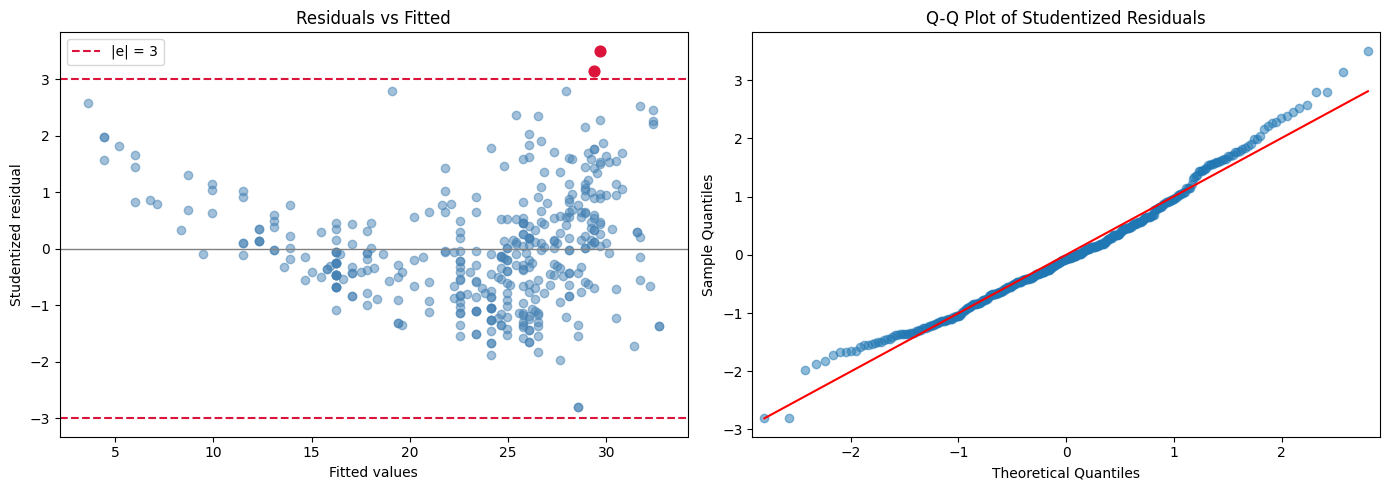

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs fitted
axes[0].scatter(diag['fitted'], diag['student_resid'], alpha=0.5, color='steelblue')
axes[0].axhline(0,  color='gray', linewidth=1)
axes[0].axhline( 3, color='crimson', linestyle='--', linewidth=1.5, label='|e| = 3')
axes[0].axhline(-3, color='crimson', linestyle='--', linewidth=1.5)
outliers = diag[diag['student_resid'].abs() > 3]
axes[0].scatter(outliers['fitted'], outliers['student_resid'], color='crimson', zorder=5, s=60)
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Studentized residual')
axes[0].set_title('Residuals vs Fitted')
axes[0].legend()

# Q-Q plot
sm.qqplot(diag['student_resid'], line='s', ax=axes[1], alpha=0.5, color='steelblue')
axes[1].set_title('Q-Q Plot of Studentized Residuals')

plt.tight_layout()
plt.show()

The residuals vs fitted plot is useful for two things at once: spotting outliers (large vertical deviations) and checking whether the residuals are randomly scattered around zero (no pattern means the linear model is a reasonable fit).

The Q-Q plot checks whether the residuals are approximately normally distributed. Points that fall far from the diagonal line represent departures from normality — which may or may not matter depending on sample size and what inference you’re doing.

## Part 2: Leverage — Detecting Unusual Predictor Values

The **leverage** of observation $i$ is the $i$-th diagonal element of the hat matrix $H = X(X^TX)^{-1}X^T$. It measures how far observation $i$’s predictor values are from the mean of the predictor distribution.

- Leverage is always between $1/n$ and 1
- The average leverage is $(p+1)/n$ where $p$ is the number of predictors
- A common threshold for flagging high-leverage points is $2(p+1)/n$

High leverage alone doesn’t mean a point is problematic — it just means it’s in an unusual region of predictor space. Whether it *influences* the model depends on whether it’s also an outlier.

In [6]:
leverage_threshold = 2 * (p + 1) / n
print(f'Leverage threshold 2(p+1)/n = {leverage_threshold:.4f}')
print(f'\nHigh-leverage observations:')
print(diag[diag['leverage'] > leverage_threshold][['horsepower', 'mpg', 'leverage']].head(10))

Leverage threshold 2(p+1)/n = 0.0102

High-leverage observations:
    horsepower   mpg  leverage
5        198.0  15.0  0.017652
6        220.0  14.0  0.025592
7        215.0  14.0  0.023641
8        225.0  14.0  0.027629
9        190.0  15.0  0.015179
13       225.0  14.0  0.027629
25       215.0  10.0  0.023641
26       200.0  10.0  0.018305
27       210.0  11.0  0.021776
28       193.0   9.0  0.016081


<StemContainer object of 3 artists>

Text(0.5, 0, 'Observation index')

Text(0, 0.5, 'Leverage')

Text(0.5, 1.0, 'Leverage by observation')

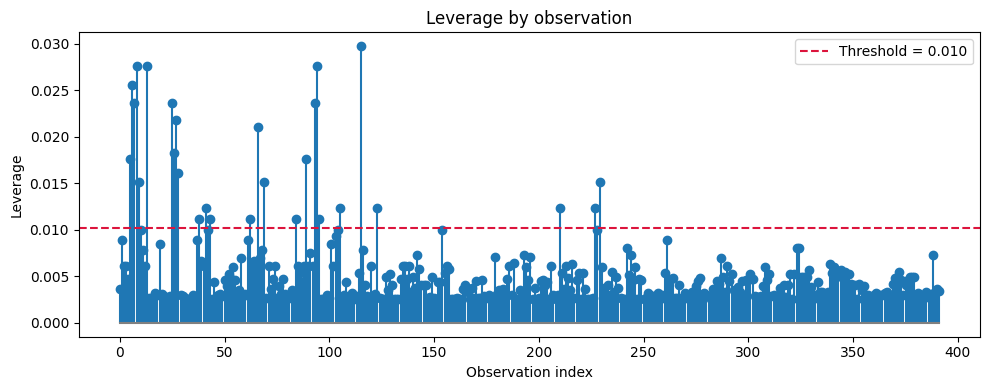

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(range(n), diag['leverage'], markerfmt='C0o', linefmt='C0-', basefmt='gray')
ax.axhline(leverage_threshold, color='crimson', linestyle='--', linewidth=1.5,
           label=f'Threshold = {leverage_threshold:.3f}')
ax.set_xlabel('Observation index')
ax.set_ylabel('Leverage')
ax.set_title('Leverage by observation')
ax.legend()
plt.tight_layout()
plt.show()

## Part 3: Cook’s Distance — Combined Influence

**Cook’s distance** measures how much all the fitted values change if observation $i$ is removed from the model. It combines both the outlier and leverage dimensions into a single number:

$$D_i = \frac{\sum_{j=1}^n (\hat{y}_j - \hat{y}_{j(i)})^2}{(p+1)\hat{\sigma}^2}$$

where $\hat{y}_{j(i)}$ is the fitted value for observation $j$ when observation $i$ is left out.

A common threshold is $D_i > 4/n$, though some use comparison to the $F$-distribution. An observation with high Cook’s distance is **influential** — removing it would noticeably change the model.

In [8]:
cooks_threshold = 4 / n
print(f"Cook's distance threshold 4/n = {cooks_threshold:.4f}")
print(f'\nInfluential observations (Cook\'s D > threshold):')
print(diag[diag['cooks_d'] > cooks_threshold][['horsepower', 'mpg', 'student_resid', 'leverage', 'cooks_d']].head(10))

Cook's distance threshold 4/n = 0.0102

Influential observations (Cook's D > threshold):
     horsepower   mpg  student_resid  leverage   cooks_d
5         198.0  15.0       1.300421  0.017652  0.015167
6         220.0  14.0       1.820523  0.025592  0.043266
7         215.0  14.0       1.654188  0.023641  0.032981
8         225.0  14.0       1.987670  0.027629  0.055708
13        225.0  14.0       1.987670  0.027629  0.055708
58         54.0  23.0      -1.725112  0.006948  0.010359
93        215.0  13.0       1.446242  0.023641  0.025251
94        225.0  12.0       1.569695  0.027629  0.034875
115       230.0  16.0       2.578033  0.029753  0.100451
152        72.0  15.0      -2.796554  0.004371  0.016872


<StemContainer object of 3 artists>

Text(0.5, 0, 'Observation index')

Text(0, 0.5, "Cook's distance")

Text(0.5, 1.0, "Cook's Distance by observation")

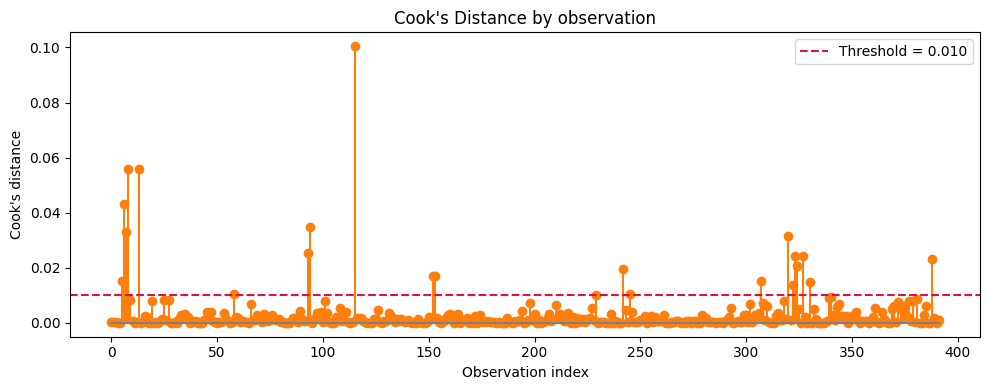

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(range(n), diag['cooks_d'], markerfmt='C1o', linefmt='C1-', basefmt='gray')
ax.axhline(cooks_threshold, color='crimson', linestyle='--', linewidth=1.5,
           label=f"Threshold = {cooks_threshold:.3f}")
ax.set_xlabel('Observation index')
ax.set_ylabel("Cook's distance")
ax.set_title("Cook's Distance by observation")
ax.legend()
plt.tight_layout()
plt.show()

## Part 4: The Full Diagnostic Plot

The standard four-panel diagnostic plot gives you all of these views at once.

Text(0.5, 0, 'Fitted values')

Text(0, 0.5, 'Studentized residual')

Text(0.5, 1.0, 'Residuals vs Fitted')

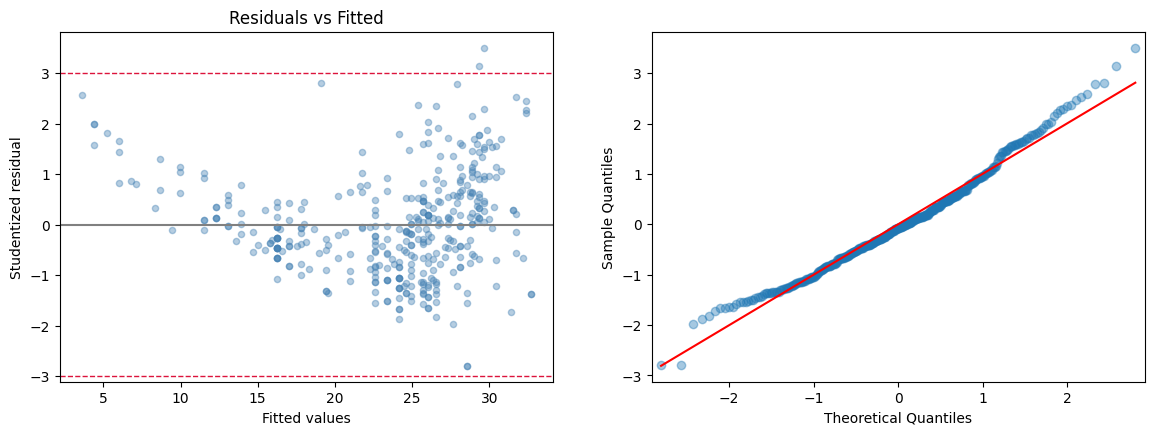

Text(0.5, 1.0, 'Normal Q-Q')

Text(0.5, 0, 'Fitted values')

Text(0, 0.5, '√|Studentized residual|')

Text(0.5, 1.0, 'Scale-Location')

Text(0.5, 0, 'Leverage')

Text(0, 0.5, 'Studentized residual')

Text(0.5, 1.0, 'Residuals vs Leverage')

Text(0.5, 1.01, 'Regression Diagnostics — MPG ~ Horsepower')

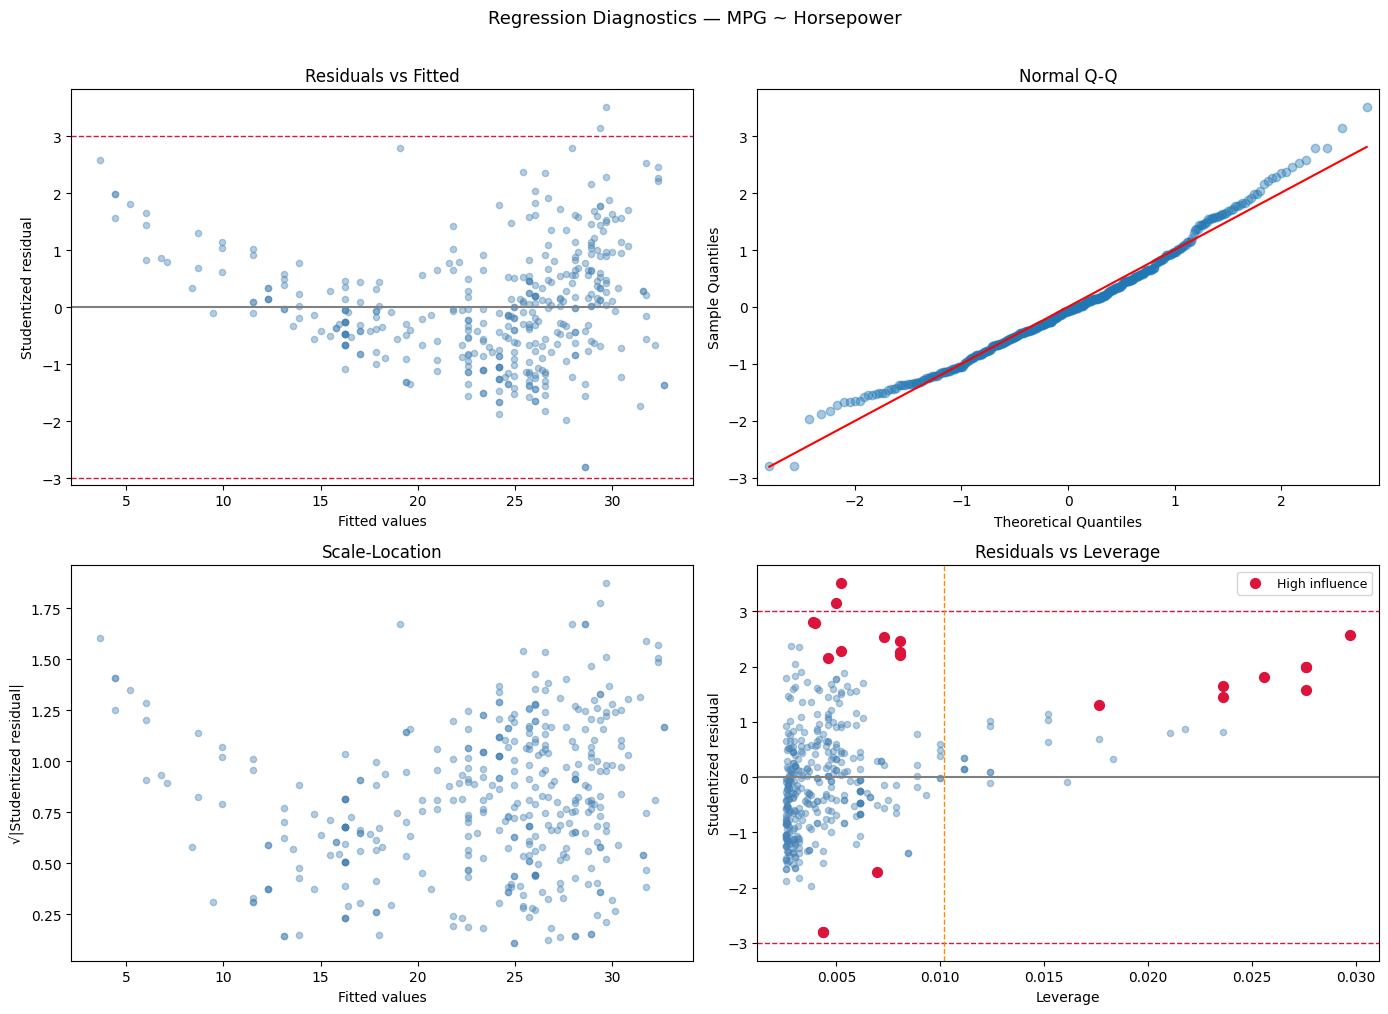

In [10]:
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig)

# 1. Residuals vs Fitted
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(diag['fitted'], diag['student_resid'], alpha=0.4, color='steelblue', s=20)
ax1.axhline(0, color='gray')
ax1.axhline( 3, color='crimson', linestyle='--', linewidth=1)
ax1.axhline(-3, color='crimson', linestyle='--', linewidth=1)
ax1.set_xlabel('Fitted values')
ax1.set_ylabel('Studentized residual')
ax1.set_title('Residuals vs Fitted')

# 2. Q-Q plot
ax2 = fig.add_subplot(gs[0, 1])
sm.qqplot(diag['student_resid'], line='s', ax=ax2, alpha=0.4, color='steelblue')
ax2.set_title('Normal Q-Q')

# 3. Scale-Location
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(diag['fitted'], np.sqrt(np.abs(diag['student_resid'])), alpha=0.4, color='steelblue', s=20)
ax3.set_xlabel('Fitted values')
ax3.set_ylabel('\u221a|Studentized residual|')
ax3.set_title('Scale-Location')

# 4. Residuals vs Leverage
ax4 = fig.add_subplot(gs[1, 1])
ax4.scatter(diag['leverage'], diag['student_resid'], alpha=0.4, color='steelblue', s=20)
ax4.axhline(0, color='gray')
ax4.axhline( 3, color='crimson', linestyle='--', linewidth=1)
ax4.axhline(-3, color='crimson', linestyle='--', linewidth=1)
ax4.axvline(leverage_threshold, color='darkorange', linestyle='--', linewidth=1)
ax4.set_xlabel('Leverage')
ax4.set_ylabel('Studentized residual')
ax4.set_title('Residuals vs Leverage')

# Flag influential points in the leverage plot
influential = diag[diag['cooks_d'] > cooks_threshold]
ax4.scatter(influential['leverage'], influential['student_resid'],
            color='crimson', zorder=5, s=50, label='High influence')
ax4.legend(fontsize=9)

plt.suptitle('Regression Diagnostics — MPG ~ Horsepower', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Reading the four panels:**

- **Residuals vs Fitted**: should look like random scatter around zero. A curved pattern suggests the linear model is misspecified (try adding a polynomial term). Fan-shaped spread suggests heteroscedasticity.
- **Normal Q-Q**: residuals should follow the diagonal line. Heavy tails or S-curves indicate non-normality.
- **Scale-Location**: similar to Residuals vs Fitted but uses $\sqrt{|e|}$. Useful for spotting heteroscedasticity — look for a flat, horizontal spread.
- **Residuals vs Leverage**: the most useful panel for finding influential points. The dangerous quadrant is upper-right (high leverage AND large residual).

## Part 5: Watching a Suspicious Point Arrive

The widget below adds a single new observation at the position you choose and shows you how it affects all three diagnostics. Try placing a point:
- Far right (high horsepower) with average MPG — high leverage, not necessarily an outlier
- Far right with very high or very low MPG — high leverage AND outlier = influential
- In the middle of the x-range with extreme MPG — outlier but low leverage

In [11]:
@interact(
    hp =widgets.IntSlider(min=40, max=300, step=5,  value=150, description='Horsepower',
                          style={'description_width': 'initial'}),
    mpg=widgets.IntSlider(min=0,  max=55,  step=1,  value=20,  description='MPG',
                          style={'description_width': 'initial'})
)
def add_point(hp, mpg):
    new_row  = pd.DataFrame({'horsepower': [hp], 'mpg': [mpg]})
    auto_aug = pd.concat([auto, new_row], ignore_index=True)
    m_aug    = smf.ols('mpg ~ horsepower', auto_aug).fit()
    inf_aug  = m_aug.get_influence()

    sr_new  = inf_aug.resid_studentized_external[-1]
    lev_new = inf_aug.hat_matrix_diag[-1]
    cd_new  = inf_aug.cooks_distance[0][-1]

    lev_thr = 2 * 2 / len(auto_aug)
    cd_thr  = 4 / len(auto_aug)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: scatter with both regression lines
    axes[0].scatter(auto['horsepower'], auto['mpg'], alpha=0.3, color='steelblue', s=15, label='Original data')
    hp_r = np.linspace(40, 300, 200)
    axes[0].plot(hp_r, model.predict(pd.DataFrame({'horsepower': hp_r})),
                 color='steelblue', linewidth=2, label='Original fit')
    axes[0].plot(hp_r, m_aug.predict(pd.DataFrame({'horsepower': hp_r})),
                 color='crimson', linewidth=2, linestyle='--', label='New fit')
    axes[0].scatter([hp], [mpg], color='crimson', s=120, zorder=5, label='New point')
    axes[0].set_xlabel('Horsepower')
    axes[0].set_ylabel('MPG')
    axes[0].set_title('Effect on regression line')
    axes[0].legend(fontsize=9)

    # Right: diagnostics for the new point
    metrics  = ['Studentized\nresidual', 'Leverage', "Cook's\ndistance"]
    values   = [sr_new, lev_new, cd_new]
    thresholds = [3, lev_thr, cd_thr]
    colors   = ['crimson' if abs(v) > t else 'steelblue'
                for v, t in zip(values, thresholds)]

    axes[1].bar(metrics, [abs(v) for v in values], color=colors, alpha=0.75)
    for i, (t, label) in enumerate(zip(thresholds, ['|e| = 3', '2(p+1)/n', '4/n'])):
        axes[1].axhline(t, color='gray', linestyle='--', linewidth=1)
    axes[1].set_ylabel('Value (absolute)')
    axes[1].set_title('Diagnostics for the new point\n(red = exceeds threshold)')

    plt.tight_layout()
    plt.show()

    flags = []
    if abs(sr_new) > 3:  flags.append(f'outlier (|e| = {sr_new:.2f})')
    if lev_new > lev_thr: flags.append(f'high leverage ({lev_new:.4f} > {lev_thr:.4f})')
    if cd_new  > cd_thr:  flags.append(f'influential (D = {cd_new:.4f} > {cd_thr:.4f})')

    if flags:
        print('Flagged as: ' + ', '.join(flags))
    else:
        print('No flags — this point does not appear unusual.')

interactive(children=(IntSlider(value=150, description='Horsepower', max=300, min=40, step=5, style=SliderStyl…

## What To Do When You Find Them

Finding outliers or high-leverage points is not the end of the analysis — it’s the beginning of an investigation.

**First, check for data errors.** An outlier might simply be a typo, a unit mismatch, or a recording error. If so, correct or remove it.

**If the point is real, understand why it’s unusual.** A genuine outlier may reveal that your model is missing a variable, that the relationship is non-linear, or that a particular subgroup behaves differently from the rest.

**Removing outliers without cause is not acceptable.** Dropping observations just because they hurt your model’s fit is p-hacking by another name. At minimum, report the analysis with and without the suspect observations and note the difference.

**High leverage without outlier status is often fine.** A point at an unusual x-value that happens to fall on the regression line isn’t causing any harm — it’s actually providing useful information about the relationship at the extremes of your predictor range.